# Solving Real Physics PDEs: 1D and 2D Poisson Equations

This notebook solves small one- and two-dimensional Poisson problems with homogeneous Dirichlet boundary conditions. After finite-difference discretization, both become linear systems

$$Lu=f,$$

where `L` is a positive definite discrete negative Laplacian. We solve each system using an inverse-like bounded polynomial transform, which is the kind of spectral primitive QSVT can express after block encoding.


## Problem, QSVT Strategy, and Quantum Relevance

**System/problem.** This notebook studies one- and two-dimensional Dirichlet Poisson boundary-value problems.

**QSVT implementation.** It uses inverse-like polynomials on a positive Laplacian spectrum. The matrices are deliberately small so the spectral rescaling, polynomial target, and validation quantities are visible in one executable notebook.

**Classical reference and quantum relevance.** Linear solves with NumPy provide the classical reference solutions. For large sparse elliptic systems, inverse polynomial transforms are the QSVT ingredient behind quantum linear-system style workflows.


## Variable definitions

- `n_points`: number of grid points in the 1D Poisson solve.
- `x`, `L`: 1D grid coordinates and Dirichlet negative-Laplacian matrix.
- `source`: 1D right-hand side vector.
- `eigenvalues`: eigenvalues of the 1D Laplacian.
- `lambda_min`, `lambda_max`: smallest and largest 1D eigenvalues.
- `gamma`: normalized lower spectral bound used by the inverse polynomial.
- `condition_number`: spectral condition number of the Laplacian.
- `A`: normalized 1D Laplacian.
- `coeffs`, `inverse_like`: inverse-polynomial coefficients and operator.
- `u_poly`, `u_direct`: polynomial and direct 1D Poisson solutions.
- `relative_error`: relative 1D solution error.
- `nx`, `ny`: 2D grid dimensions.
- `x2`, `y2`, `L2`: 2D grid coordinates and Laplacian.
- `X2`, `Y2`: coordinate meshgrids for the 2D source.
- `source2`, `source2_vec`: 2D source field and flattened source vector.
- `eigenvalues2`, `lambda_min2`, `lambda_max2`, `gamma2`, `condition_number2`: 2D spectral diagnostics.
- `degree2`, `A2`, `coeffs2`: 2D inverse-polynomial parameters.
- `u_poly2_vec`, `u_direct2_vec`, `u_poly2`, `u_direct2`, `difference2`: 2D polynomial/direct solutions and their difference.
- `fig`, `axes`, `cmap`, and similar names are plotting helpers.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from qsvt.design import design_inverse_polynomial
from qsvt.polynomials import eval_polynomial
from qsvt.pde import dirichlet_laplacian_1d, dirichlet_laplacian_2d
from qsvt.spectral import apply_polynomial_to_hermitian, eigh_hermitian

np.set_printoptions(precision=4, suppress=True)

## 1D boundary-value problem

Use the standard second-difference negative Laplacian with zero boundary values. The source term combines smooth Fourier modes so the exact continuum behavior is easy to interpret.


In [2]:
# A deliberately small grid keeps the condition number in the range where
# the package's current educational inverse-polynomial helper is effective.
n_points = 6
x, L = dirichlet_laplacian_1d(n_points)

source = np.sin(np.pi * x) + 0.35 * np.sin(3.0 * np.pi * x)
eigenvalues, _ = eigh_hermitian(L)

print(f"First Eigenvalue [inverse grid-length units]: {eigenvalues[0]}")
print(f"Last Eigenvalue [inverse grid-length units]: {eigenvalues[-1]}")

First Eigenvalue [inverse grid-length units]: 9.705050945562935
Last Eigenvalue [inverse grid-length units]: 186.29494905443704


## Poisson boundary-value geometry

The inverse-polynomial solve represents a Dirichlet Poisson problem: a source drives a potential with fixed boundary values.


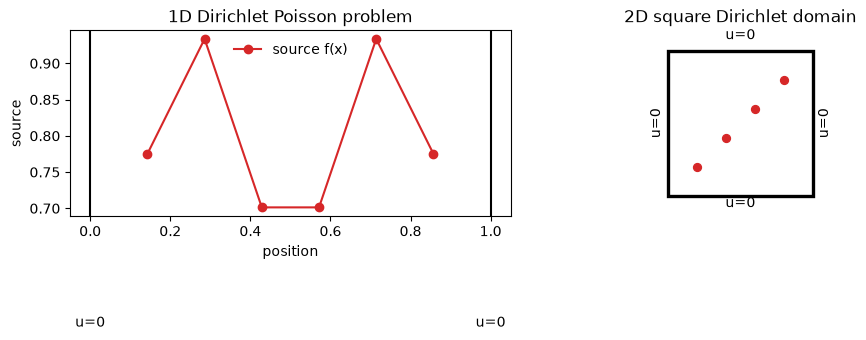

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.0), constrained_layout=True)

axes[0].plot(x, source, "o-", color="tab:red", label="source f(x)")
for boundary in [0.0, 1.0]:
    axes[0].axvline(boundary, color="black", linewidth=1.5)
    axes[0].text(boundary, min(source) - 0.15, "u=0", ha="center", va="top")
axes[0].set_xlabel("position")
axes[0].set_ylabel("source")
axes[0].set_title("1D Dirichlet Poisson problem")
axes[0].legend(frameon=False)

axes[1].add_patch(
    plt.Rectangle((0, 0), 1, 1, fill=False, linewidth=2.4, edgecolor="black")
)
axes[1].text(0.5, -0.08, "u=0", ha="center")
axes[1].text(0.5, 1.08, "u=0", ha="center")
axes[1].text(-0.08, 0.5, "u=0", rotation=90, ha="center", va="center")
axes[1].text(1.08, 0.5, "u=0", rotation=90, ha="center", va="center")
axes[1].scatter(
    np.linspace(0.2, 0.8, 4),
    np.linspace(0.2, 0.8, 4),
    s=32,
    color="tab:red",
    label="source grid",
)
axes[1].set_xlim(-0.14, 1.14)
axes[1].set_ylim(-0.14, 1.14)
axes[1].set_aspect("equal")
axes[1].set_title("2D square Dirichlet domain")
axes[1].axis("off")
plt.show()

## Normalize the operator for an inverse polynomial

`design_inverse_polynomial(gamma, degree)` approximates `gamma / y` on the positive part of the spectrum. For a positive definite Laplacian, set

$$A = L / \lambda_{\max}, \qquad \gamma = \lambda_{\min}/\lambda_{\max}.$$

Then

$$L^{-1} \approx \frac{P(A)}{\gamma\lambda_{\max}}.$$

The condition number controls how small `gamma` is. Smaller `gamma` generally needs a higher-degree polynomial, and high-resolution PDE grids quickly become challenging for a low-degree bounded inverse polynomial.

In [4]:
lambda_min = eigenvalues[0]
lambda_max = eigenvalues[-1]
gamma = lambda_min / lambda_max
condition_number = lambda_max / lambda_min

A = L / lambda_max

print(f"Gamma: {gamma}")
print(f"Condition Number: {condition_number}")

Gamma: 0.05209508360168709
Condition Number: 19.1956693580892


## Solve with the inverse-like polynomial

The polynomial solution is compared to NumPy's direct linear solve for the same finite-difference system.

In [5]:
degree = 45
coeffs = design_inverse_polynomial(gamma=gamma, degree=degree)

inverse_like = apply_polynomial_to_hermitian(A, coeffs) / (gamma * lambda_max)
u_poly = inverse_like @ source

u_direct = np.linalg.solve(L, source)
relative_error = np.linalg.norm(u_poly - u_direct) / np.linalg.norm(u_direct)

print(f"Relative Error: {relative_error}")

Relative Error: 0.014154496734875139


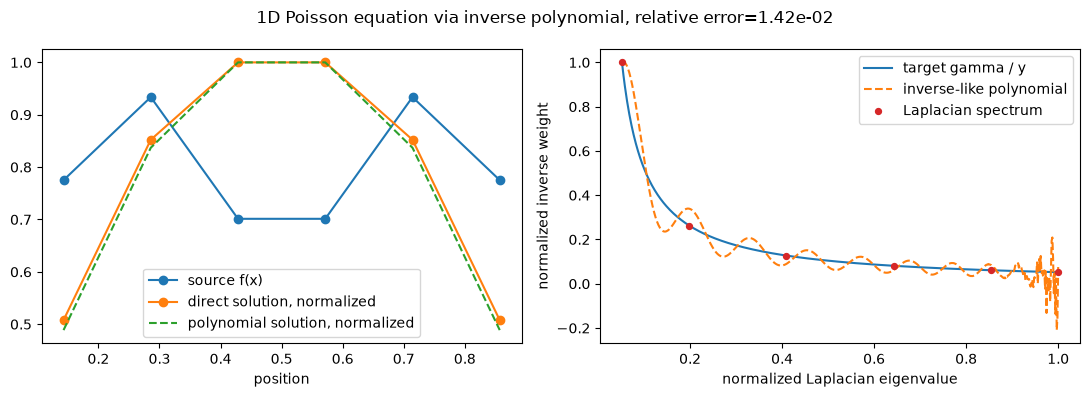

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(x, source, "o-", label="source f(x)")
axes[0].plot(
    x, u_direct / np.max(np.abs(u_direct)), "o-", label="direct solution, normalized"
)
axes[0].plot(
    x, u_poly / np.max(np.abs(u_poly)), "--", label="polynomial solution, normalized"
)
axes[0].set_xlabel("position")
axes[0].legend()

ys = np.linspace(gamma, 1.0, 600)
axes[1].plot(ys, gamma / ys, label="target gamma / y")
axes[1].plot(ys, eval_polynomial(coeffs, ys), "--", label="inverse-like polynomial")
axes[1].scatter(
    eigenvalues / lambda_max,
    gamma / (eigenvalues / lambda_max),
    color="tab:red",
    s=18,
    zorder=3,
    label="Laplacian spectrum",
)
axes[1].set_xlabel("normalized Laplacian eigenvalue")
axes[1].set_ylabel("normalized inverse weight")
axes[1].legend()

fig.suptitle(
    f"1D Poisson equation via inverse polynomial, relative error={relative_error:.2e}"
)
plt.tight_layout()
plt.show()

## 2D boundary-value problem

The 2D case uses a Kronecker-sum Dirichlet Laplacian. A deliberately small grid keeps the condition number in the range where the package's current educational inverse-polynomial helper remains useful.


In [7]:
nx = 6
ny = 6
x2, y2, L2 = dirichlet_laplacian_2d(nx, ny)
X2, Y2 = np.meshgrid(x2, y2, indexing="ij")

source2 = np.sin(np.pi * X2) * np.sin(np.pi * Y2)
source2 += 0.3 * np.sin(2.0 * np.pi * X2) * np.sin(np.pi * Y2)
source2_vec = source2.reshape(-1)

eigenvalues2, _ = eigh_hermitian(L2)
lambda_min2 = eigenvalues2[0]
lambda_max2 = eigenvalues2[-1]
gamma2 = lambda_min2 / lambda_max2
condition_number2 = lambda_max2 / lambda_min2

print(f"Gamma: {gamma2}")
print(f"Condition Number: {condition_number2}")
print(f"Matrix Shape [rows, cols]: {L2.shape}")

Gamma: 0.05209508360168687
Condition Number: 19.195669358089283
Matrix Shape [rows, cols]: (36, 36)


## 2D inverse-like polynomial solve

As in 1D, set `A2 = L2 / lambda_max2` and rescale the polynomial output by `1 / (gamma2 * lambda_max2)`.


In [8]:
degree2 = 45
A2 = L2 / lambda_max2
coeffs2 = design_inverse_polynomial(gamma=gamma2, degree=degree2)

u_poly2_vec = apply_polynomial_to_hermitian(A2, coeffs2) @ source2_vec
u_poly2_vec = u_poly2_vec / (gamma2 * lambda_max2)
u_direct2_vec = np.linalg.solve(L2, source2_vec)

relative_error2 = np.linalg.norm(u_poly2_vec - u_direct2_vec) / np.linalg.norm(
    u_direct2_vec
)
print(f"Relative Error: {relative_error2}")

Relative Error: 0.03496500256208569


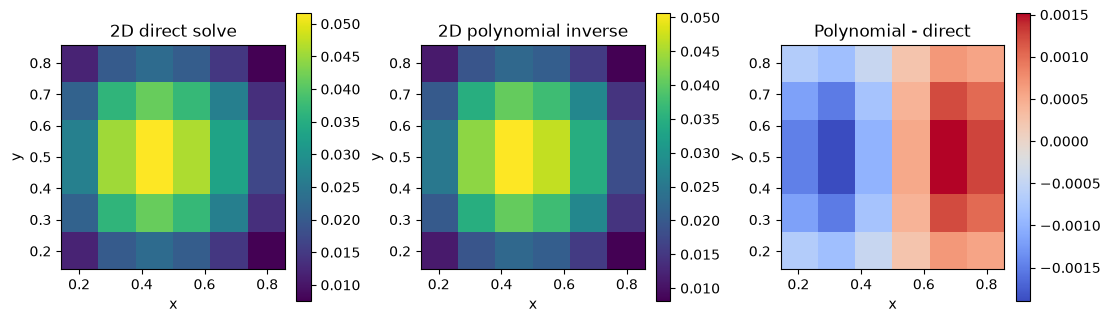

In [9]:
u_poly2 = u_poly2_vec.reshape(nx, ny)
u_direct2 = u_direct2_vec.reshape(nx, ny)
difference2 = u_poly2 - u_direct2

fig, axes = plt.subplots(1, 3, figsize=(11, 3.6), constrained_layout=True)
for ax, field, title, cmap in zip(
    axes,
    [u_direct2, u_poly2, difference2],
    ["2D direct solve", "2D polynomial inverse", "Polynomial - direct"],
    ["viridis", "viridis", "coolwarm"],
):
    image = ax.imshow(
        field.T,
        origin="lower",
        extent=[x2[0], x2[-1], y2[0], y2[-1]],
        cmap=cmap,
        aspect="equal",
    )
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    fig.colorbar(image, ax=ax, shrink=0.82)

plt.show()

## Executable block-encoded QSVT solve

The spectral calculations above isolate the approximation idea. This final small 1D instance connects the full validation chain: finite-difference discretization, dense direct and conjugate-gradient baselines, tolerance-driven inverse-polynomial selection, Pauli-LCU PrepSelPrep access, phase synthesis, logical resources, and an actual PennyLane QNode execution. The four-point grid keeps the circuit finite enough to inspect; it does not make state preparation, postselection, or full-vector readout scalable.


In [10]:
from qsvt.stable import poisson_qsvt_workflow
from qsvt.notebook import display_table

poisson_flagship = poisson_qsvt_workflow(
    4,
    tolerance=0.4,
    min_degree=5,
    max_degree=5,
    access_model="prepselprep",
    num_points=401,
    execute=True,
)
cg_solution = np.asarray(poisson_flagship.conjugate_gradient["solution"])
solver_rows = [
    {"solver": "dense direct", "relative_error": 0.0, "residual": np.linalg.norm(poisson_flagship.matrix @ poisson_flagship.direct_solution - poisson_flagship.rhs)},
    {"solver": "conjugate gradient", "relative_error": np.linalg.norm(cg_solution - poisson_flagship.direct_solution) / np.linalg.norm(poisson_flagship.direct_solution), "residual": poisson_flagship.conjugate_gradient["residual_norm"]},
    {"solver": "QSVT polynomial", "relative_error": poisson_flagship.polynomial_relative_error, "residual": poisson_flagship.polynomial_residual_norm},
    {"solver": "QSVT circuit", "relative_error": poisson_flagship.circuit_relative_error, "residual": np.linalg.norm(poisson_flagship.matrix @ poisson_flagship.circuit_solution - poisson_flagship.rhs)},
]
display_table(
    "Poisson solver comparison",
    solver_rows,
    [
        ("solver", lambda row: row["solver"]),
        ("relative solution error", lambda row: row["relative_error"]),
        ("residual norm", lambda row: row["residual"]),
    ],
    layout="rows",
)
display_table(
    "Component error ledger",
    [{"component": key, "value": value} for key, value in poisson_flagship.error_budget.items()],
    [("component", lambda row: row["component"]), ("error", lambda row: row["value"])],
    layout="rows",
)
poisson_acceptance = poisson_flagship.as_report()["acceptance"]
display_table(
    "Flagship acceptance checks",
    poisson_acceptance["checks"],
    [
        ("criterion", lambda row: row["id"]),
        ("required for scope", lambda row: row["required_for_scope"]),
        ("passed", lambda row: row["passed"]),
    ],
    layout="rows",
)
print(f"selected degree: {poisson_flagship.degree_search.chosen_degree}")
print(f"normalization alpha: {poisson_flagship.block_encoding_spec.alpha:.6f}")
print(f"resource model: {poisson_flagship.resource_estimate.estimator_model}")
print(f"acceptance: {poisson_acceptance['status']} (scope={poisson_acceptance['scope']}, full_qsvt={poisson_acceptance['full_qsvt_acceptance']})")

Poisson solver comparison
-------------------------
solver              relative solution error  residual norm
------------------  -----------------------  -------------
dense direct        0                        1.29e-15     
conjugate gradient  2.81e-16                 1.04e-15     
QSVT polynomial     0.325                    0.5139       
QSVT circuit        0.325                    0.5139       
Component error ledger
----------------------
component                        error   
-------------------------------  --------
discretization_error             0.03356 
polynomial_approximation_error   0.325   
phase_reconstruction_error       6.95e-13
circuit_vs_polynomial_error      1.00e-12
maximum_sampling_standard_error  n/a     
additive_error_proxy             0.3586  
Flagship acceptance checks
--------------------------
criterion                  required for scope  passed
-------------------------  ------------------  ------
classical_reference        True                Tru

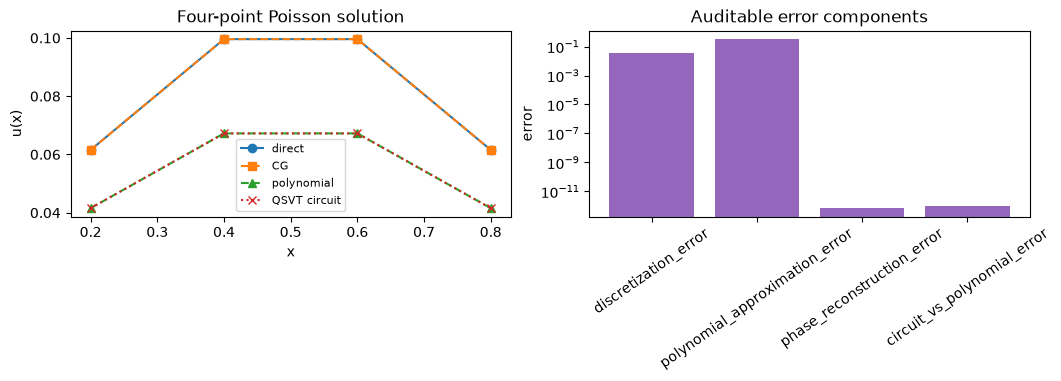

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.7), constrained_layout=True)
axes[0].plot(poisson_flagship.grid, poisson_flagship.direct_solution, "o-", label="direct")
axes[0].plot(poisson_flagship.grid, cg_solution, "s--", label="CG")
axes[0].plot(poisson_flagship.grid, poisson_flagship.polynomial_solution, "^--", label="polynomial")
axes[0].plot(poisson_flagship.grid, poisson_flagship.circuit_solution, "x:", label="QSVT circuit")
axes[0].set_xlabel("x")
axes[0].set_ylabel("u(x)")
axes[0].set_title("Four-point Poisson solution")
axes[0].legend(fontsize=8)

ledger = {key: value for key, value in poisson_flagship.error_budget.items() if value is not None and key != "additive_error_proxy"}
axes[1].bar(list(ledger), list(ledger.values()), color="tab:purple")
axes[1].set_yscale("log")
axes[1].set_ylabel("error")
axes[1].set_title("Auditable error components")
axes[1].tick_params(axis="x", rotation=35)
plt.show()

## What this demonstrates

The Poisson equation is an elliptic physics PDE, and its discretization is a linear-system problem. The 1D and 2D sections show the inverse-like polynomial acting as a regularized spectral inverse, while the executable four-point workflow demonstrates how an accuracy target, access model, phase synthesis, resource model, circuit validation, and component error ledger fit together. The condition-number comparison shows why higher-dimensional or finer-grid PDE systems quickly become more demanding.


## Validation

Compact checks for the expected 1D and 2D numerical behavior and the executable block-encoded QSVT path.


In [12]:
assert np.isfinite(relative_error)
assert relative_error < 0.05
assert gamma > 0.0
assert condition_number < 25.0
assert u_poly.shape == u_direct.shape == source.shape

assert np.isfinite(relative_error2)
assert relative_error2 < 0.15
assert gamma2 > 0.0
assert condition_number2 < 20.0
assert u_poly2.shape == u_direct2.shape == source2.shape

assert poisson_flagship.conjugate_gradient["converged"]
assert poisson_flagship.degree_search.met_tolerance
assert poisson_flagship.execution is not None and poisson_flagship.execution.succeeded
assert poisson_flagship.circuit_relative_error is not None
assert np.isclose(poisson_flagship.circuit_relative_error, poisson_flagship.polynomial_relative_error, atol=1e-8)

print(f"1D condition_number: {condition_number:.3f}")
print(f"1D relative_error: {relative_error:.3e}")
print(f"2D condition_number: {condition_number2:.3f}")
print(f"2D relative_error: {relative_error2:.3e}")
print(f"QSVT circuit relative_error: {poisson_flagship.circuit_relative_error:.3e}")
print("validation: passed")

1D condition_number: 19.196
1D relative_error: 1.415e-02
2D condition_number: 19.196
2D relative_error: 3.497e-02
QSVT circuit relative_error: 3.250e-01
validation: passed
